In [1]:
import pandas as pd
import numpy as np

from prophet import Prophet

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv(
    "../outputs/cleaned_retail.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Quarter,Week,Day,DayName,Hour,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,4,49,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,4,49,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,4,49,1,Tuesday,7,False


In [3]:
daily_sales = (

    df.groupby(df["InvoiceDate"].dt.date)["TotalSales"]

    .sum()

    .reset_index()

)

In [4]:
daily_sales.columns = [

    "ds",

    "y"

]

daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

daily_sales.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


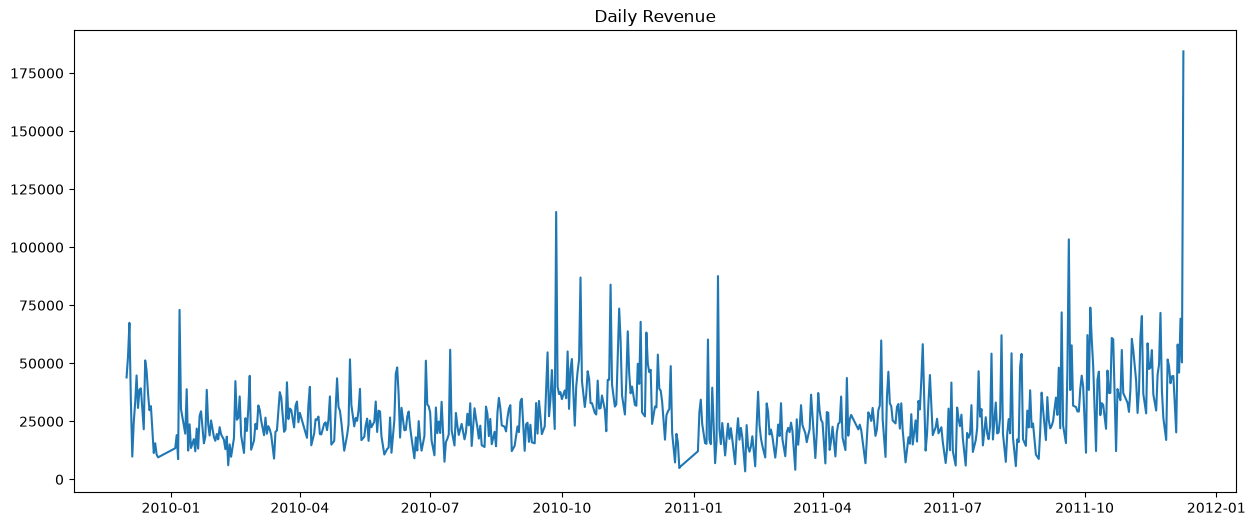

In [5]:
plt.figure(figsize=(15,6))

plt.plot(

    daily_sales["ds"],

    daily_sales["y"]

)

plt.title("Daily Revenue")

plt.show()

In [6]:
train = daily_sales.iloc[:-30]

test = daily_sales.iloc[-30:]

In [7]:
model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=True,

    daily_seasonality=False

)

model.fit(train)

08:37:04 - cmdstanpy - INFO - Chain [1] start processing
08:37:06 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(

    periods=30

)

forecast = model.predict(future)

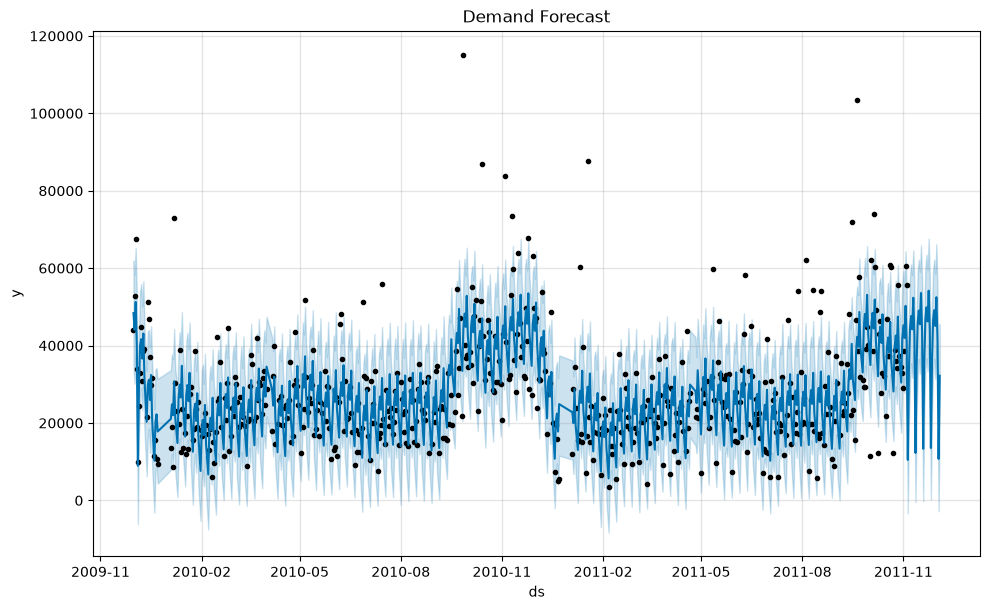

In [9]:
fig = model.plot(forecast)

plt.title("Demand Forecast")

plt.show()

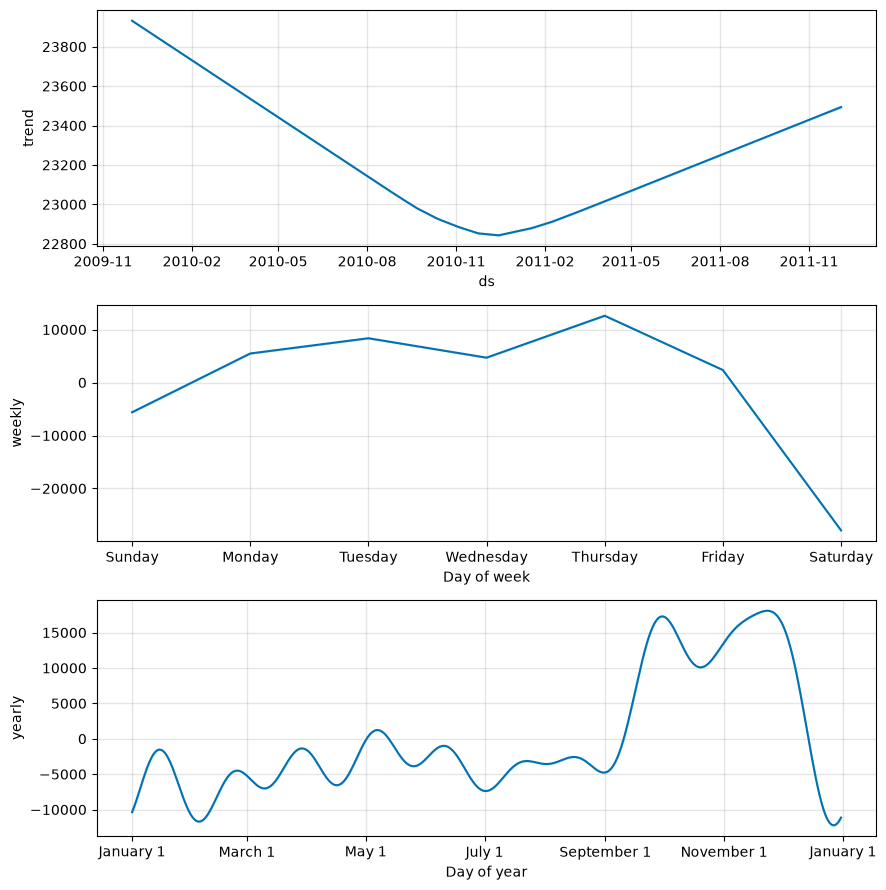

In [10]:
fig2 = model.plot_components(forecast)

plt.show()

In [11]:
forecast.tail(30)[

    [

        "ds",

        "yhat",

        "yhat_lower",

        "yhat_upper"

    ]

]

,ds,yhat,yhat_lower,yhat_upper
574,2011-11-05,10458.905395,-3354.792097,23741.581313
575,2011-11-06,33069.468457,19575.404628,46397.048197
576,2011-11-07,44460.727921,30301.942805,58009.927705
577,2011-11-08,47613.723018,35373.294445,61012.326447
578,2011-11-09,44201.290386,31659.757654,58247.750311
579,2011-11-10,52346.941475,38583.217410,64608.838453
580,2011-11-11,42313.232368,29252.546951,55803.625888
581,2011-11-12,12247.242139,-451.426315,26305.176284
582,2011-11-13,34718.431045,20759.085996,48010.360824
583,2011-11-14,45982.726449,32076.311863,59383.395704


In [12]:
pred = forecast.tail(30)["yhat"].values

actual = test["y"].values

In [13]:
mae = mean_absolute_error(
    actual,
    pred
)
print(mae)

22049.95722219972


In [15]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)
print(rmse)

35069.996584666456


In [16]:
mape = np.mean(
    np.abs(
        (
            actual-pred
        )/actual
    )
)*100
print(mape)

46.05446272775694


In [17]:
forecast.to_csv(

    "../outputs/demand_forecast.csv",

    index=False

)